# Laboratory 2.3: Linear Regression

In this practice you will build your own Linear Regression model. As you _should_ remember, we have seen in class how to obtain the optimal values for the parameters in a linear regression model. If you need to refresh your memory, check the slides from theory for the formula for the model optimization.

For the final part of this practice you will also need the following dataset:
- **winequality.csv**: Dataset with several input variables and a continuous output variable to determine wine quality. You can get more information from the [original repository](https://archive.ics.uci.edu/dataset/186/wine+quality).


In addition, we will be using the following libraries:
- Data management:
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)
- Modelling:
    - [scikit-learn](https://scikit-learn.org)
- Plotting:
    - [seaborn](https://seaborn.pydata.org/)
    - [matplotlib](https://matplotlib.org/)

In [1]:
# Import here whatever you may need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import scikit.learn as skl

In [2]:
# Define data to use in this practice
# TODO: Extract the ndarray data from the class chapter (slide 17 from 02-03: ML techniques: Linear and logistic regression)
x = np.array([0, 3, 2, 1, 4, 6, 7, 8, 9, 10])
y = np.array([2, 3, 2, 4, 5, 7, 9, 9, 10, 13])

### Custom Linear Regression model

In [3]:
class LinearRegressor:
    """
    Linear Regression model that can perform both simple and multiple linear regression.

    Attributes:
        coefficients (np.ndarray): Coefficients of the independent variables in the regression model.
        intercept (float): Intercept of the regression model.
    """

    def __init__(self):
        """Initializes the LinearRegressor model with default coefficient and intercept values."""
        self.coefficients = None
        self.intercept = None

    def fit_simple(self, X, y):
        """
        Fit the model using simple linear regression (one independent variable).

        This method calculates the coefficients for a linear relationship between
        a single predictor variable X and a response variable y.

        Args:
            X (np.ndarray): Independent variable data (1D array).
            y (np.ndarray): Dependent variable data (1D array).

        Returns:
            None: Modifies the model's coefficients and intercept in-place.
        """
        if np.ndim(X) > 1:
            X = X.reshape(1, -1)

        mean_x = np.mean(X)
        mean_y = np.mean(y)
        cov = np.sum((X - mean_x) * (y - mean_y))
        var = np.sum((X - mean_x) ** 2)

        self.coefficients = cov/var
        self.intercept = np.mean(y) - self.coefficients*np.mean(X)


    '''
    This part of the model you will only need for the last part of the notebook
    
    Do this **ONLY when you reach the end, not before**
    
    To implement this function you will need the analytical solution to the parameters in the multivariate case, 
    which implies you have to solve the optimization problem in slide 16, chapter 02-03: ML techniques: Linear and logistic regression
    '''
    def fit_multiple(self, X, y):
        """
        Fit the model using multiple linear regression (more than one independent variable).

        This method applies the matrix approach to calculate the coefficients for
        multiple linear regression.

        Args:
            X (np.ndarray): Independent variable data (2D array where each column is a variable).
            y (np.ndarray): Dependent variable data (1D array).

        Returns:
            None: Modifies the model's coefficients and intercept in-place.
        """
        # TODO: Train linear regression model with multiple coefficients
        X_augmented = np.c_[np.ones(X.shape[0]), X]
        self.coefficients = np.linalg.inv(X_augmented.T @ X_augmented) @ (X_augmented.T @ y)
        self.intercept = self.coefficients[0]
        self.coefficients = self.coefficients[1:]

    def predict(self, X):
        """
        Predict the dependent variable values using the fitted model.

        Args:
            X (np.ndarray): Independent variable data (1D or 2D array).

        Returns:
            np.ndarray: Predicted values of the dependent variable.

        Raises:
            ValueError: If the model is not yet fitted.
        """
        if self.coefficients is None or self.intercept is None:
            raise ValueError("Model is not yet fitted")

        if np.ndim(X) == 1:
            # TODO: Predict when X is only one variable
            predictions = self.intercept + self.coefficients*X
        else:
            # TODO: Predict when X is more than one variable
            predictions = self.intercept + X @ self.coefficients
        return predictions

In [4]:
### Train your linear regression model
linreg = LinearRegressor()
linreg.fit_simple(x, y)

In [5]:
def evaluate_regression(y_true, y_pred):
    """
    Evaluates the performance of a regression model by calculating R^2, RMSE, and MAE.

    Args:
        y_true (np.ndarray): True values of the dependent variable.
        y_pred (np.ndarray): Predicted values by the regression model.

    Returns:
        dict: A dictionary containing the R^2, RMSE, and MAE values.
    """
    # R^2 Score
    #r_squared = np.corrcoef(y_true, y_pred)[0,1]**2
    r_squared = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

    # Root Mean Squared Error
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))

    # Mean Absolute Error
    mae = np.mean(np.abs(y_true - y_pred))

    return {
        "R2": r_squared,
        "RMSE": rmse,
        "MAE": mae
    }


In [6]:
# Obtain regression performance metrics
y_pred = linreg.predict(x)
evaluation_metrics = evaluate_regression(y, y_pred)
print(evaluation_metrics)

{'R2': 0.9201359388275275, 'RMSE': 1.0126472956832235, 'MAE': 0.8945454545454549}


### Scikit-Learn comparison

In [7]:
### Compare your model with sklearn linear regression model
# TODO : Import Linear regression from sklearnç
from sklearn.linear_model import LinearRegression

# Assuming your data is stored in x and y
# TODO : Reshape x to be a 2D array, as scikit-learn expects 2D inputs for the features
x_reshaped = x.reshape(-1, 1)

# Create and train the scikit-learn model
# TODO : Train the LinearRegression model
sklearn_model = LinearRegression()
sklearn_model.fit(x_reshaped, y)

# Now, you can compare coefficients and intercepts between your model and scikit-learn's model
print("Custom Model Coefficient:", linreg.coefficients)
print("Custom Model Intercept:", linreg.intercept)
print("Scikit-Learn Coefficient:", sklearn_model.coef_[0])
print("Scikit-Learn Intercept:", sklearn_model.intercept_)


Custom Model Coefficient: 1.0363636363636364
Custom Model Intercept: 1.2181818181818187
Scikit-Learn Coefficient: 1.036363636363637
Scikit-Learn Intercept: 1.2181818181818151


### Anscombe's quartet

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load Anscombe's quartet
# These four datasets are the same as in slide 19 of chapter 02-03: Linear and logistic regression
anscombe = sns.load_dataset("anscombe")

# Anscombe's quartet consists of four datasets
# TODO: Construct an array that contains, for each entry, the identifier of each dataset
datasets = anscombe["dataset"].unique()

models = {}
for dataset in datasets:

    # Filter the data for the current dataset
    # TODO
    data = anscombe[anscombe["dataset"] == dataset]

    # Create a linear regression model
    # TODO
    model = LinearRegressor()

    # Fit the model
    # TODO
    # Predictor, make it 1D for your custom model
    X = data["x"].values
    # Response
    y = data["y"].values
    model.fit_simple(X, y)

    # Create predictions for dataset
    # TODO
    y_pred = model.predict(X)

    # Store the model for later use
    models[dataset] = model

    # Print coefficients for each dataset
    print(f"Dataset {dataset}: Coefficient: {model.coefficients}, Intercept: {model.intercept}")

    evaluation_metrics = evaluate_regression(y, y_pred)

    # Print evaluation metrics for each dataset
    print(f"R2: {evaluation_metrics['R2']}, RMSE: {evaluation_metrics['RMSE']}, MAE: {evaluation_metrics['MAE']}")

Dataset I: Coefficient: 0.5000909090909091, Intercept: 3.0000909090909103
R2: 0.666542459508775, RMSE: 1.1185497916336296, MAE: 0.8374049586776859
Dataset II: Coefficient: 0.49999999999999994, Intercept: 3.000909090909091
R2: 0.6662420337274843, RMSE: 1.1191023557497448, MAE: 0.967933884297521
Dataset III: Coefficient: 0.49972727272727274, Intercept: 3.0024545454545457
R2: 0.6663240410665592, RMSE: 1.118285693623049, MAE: 0.7159669421487604
Dataset IV: Coefficient: 0.49990909090909097, Intercept: 3.0017272727272726
R2: 0.6667072568984653, RMSE: 1.1177286221293936, MAE: 0.902727272727273



Once all models are trained (one for each dataset), we will plot the results of the fit alongside each point set

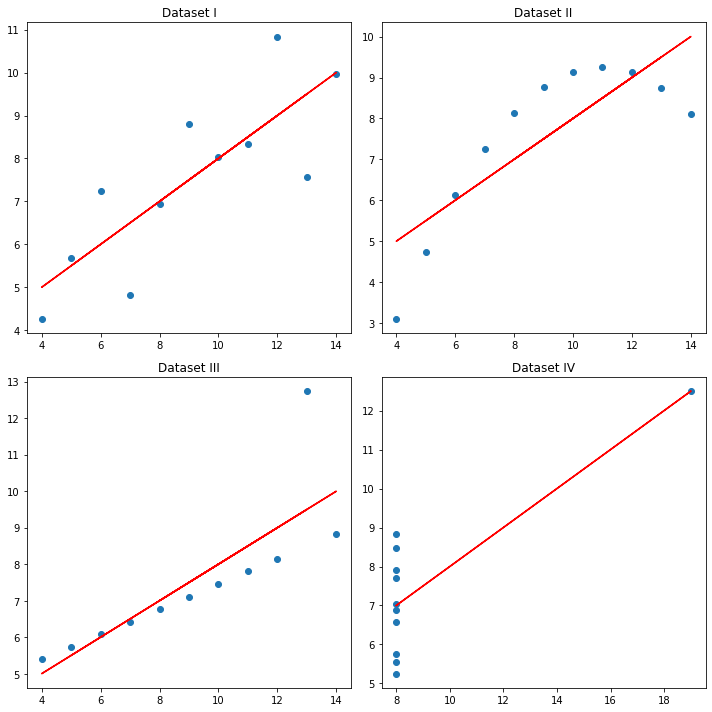

In [9]:
# Visualizing the datasets with their regression lines
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()

for i, dataset in enumerate(datasets):

    # TODO: Select the dataset for each case
    data = anscombe[anscombe["dataset"] == dataset]
    axs[i].scatter(data['x'], data['y'])

    # TODO: Plot the data and the fit (fill the "None" value)
    axs[i].plot(data['x'], models[dataset].predict(data['x']), color='red')
    axs[i].set_title(f"Dataset {dataset}")

plt.tight_layout()
plt.show()


### Multiple variable linear regression

In this section, we are going to use the dataset of the quality of red wines based on chemical measurements. The original dataset can be found in the [UCI Repository](https://archive.ics.uci.edu/dataset/186/wine+quality).

In [10]:
import pandas as pd

# TODO
wine_data = pd.read_csv("winequality.csv", sep=";")

In [11]:
# Divide dataset between inputs and output

# TODO
inputs = wine_data.columns[:-1]
output = 'quality'

X = wine_data[inputs]
y = wine_data[output]

In [12]:
# Train multiple regression model
linreg_multiple = LinearRegressor()
linreg_multiple.fit_multiple(X, y)

In [13]:
# Obtain regression performance metrics
y_pred = linreg_multiple.predict(X)
evaluation_metrics = evaluate_regression(y, y_pred)
print(evaluation_metrics)

{'R2': 0.3605517030386881, 'RMSE': 0.6455750670692048, 'MAE': 0.5004899638235994}
